## Hospital Readmission Risk Prediction
This notebook develops and compares multiple machine learning models to predict hospital readmission risk using structured healthcare data. The objective is to identify high-risk patients early and support better clinical decision-making.

## Import Libraries


In [65]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV




## Load Dataset



In [6]:
# Path to dataset
data_path = "../data/hospital_readmission_cleaned.xlsx"

# Load dataset
df = pd.read_excel(data_path)

# Quick preview
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (45095, 19)

First 5 rows:


,Year,Period of coverage,Breakdown,Level,Level description,Age Breakdown,Sex Breakdown,Diagnosis Breakdown,Method,Indicator value,Lower CI (95%),Upper CI (95%),Lower CI (99.8%),Upper CI (99.8%),Numerator,Denominator,Expected,Banding1,Warnings2
0,2014/15,01/04/2014 to 31/03/2015,England,England,England,All,Persons,Stroke (I61* to I64*),Trend,11.6,11.3,11.9,11.1,12.0,6630,57268,6630.0,NaN,NaN
1,2015/16,01/04/2015 to 31/03/2016,England,England,England,All,Persons,Stroke (I61* to I64*),Trend,11.6,11.4,11.9,11.2,12.1,6816,58520,6774.9,NaN,NaN
2,2016/17,01/04/2016 to 31/03/2017,England,England,England,All,Persons,Stroke (I61* to I64*),Trend,11.7,11.4,11.9,11.2,12.1,6834,58586,6782.6,NaN,NaN
3,2017/18,01/04/2017 to 31/03/2018,England,England,England,All,Persons,Stroke (I61* to I64*),Trend,11.8,11.5,12.1,11.4,12.3,7049,59663,6907.3,NaN,NaN
4,2018/19,01/04/2018 to 31/03/2019,England,England,England,All,Persons,Stroke (I61* to I64*),Trend,12.2,11.9,12.5,11.8,12.7,7406,60672,7024.1,NaN,NaN


## Initial Data Inspection

We inspect the dataset to understand its structure, data types, missing values, and summary statistics.

In [42]:
# Dataset info
df.info()

# Missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 45095 entries, 0 to 45094
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 45095 non-null  str    
 1   period_of_coverage   45095 non-null  str    
 2   breakdown            45095 non-null  str    
 3   level                45095 non-null  str    
 4   level_description    45095 non-null  str    
 5   age_breakdown        45095 non-null  str    
 6   sex_breakdown        45095 non-null  str    
 7   diagnosis_breakdown  45095 non-null  str    
 8   method               45095 non-null  str    
 9   indicator_value      45095 non-null  float64
 10  lower_ci_95%         45095 non-null  float64
 11  upper_ci_95%         45095 non-null  float64
 12  lower_ci_99.8%       45095 non-null  float64
 13  upper_ci_99.8%       45095 non-null  float64
 14  numerator            45095 non-null  object 
 15  denominator          45095 non-null  object 
 1

year                       0
period_of_coverage         0
breakdown                  0
level                      0
level_description          0
age_breakdown              0
sex_breakdown              0
diagnosis_breakdown        0
method                     0
indicator_value            0
lower_ci_95%               0
upper_ci_95%               0
lower_ci_99.8%             0
upper_ci_99.8%             0
numerator                  0
denominator                0
expected                   0
banding1                  66
warnings2              17713
readmission_risk           0
dtype: int64

### Missing Values Heatmap

This heatmap provides a visual overview of missing values across the dataset. It helps identify whether missingness is concentrated in specific variables or spread throughout the data.

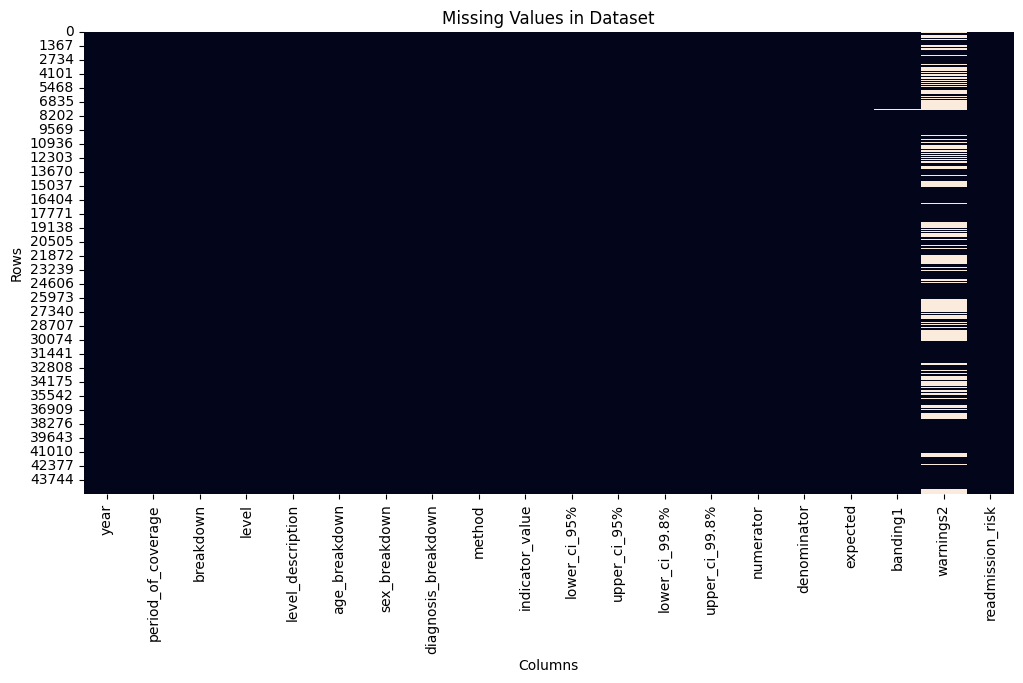

In [44]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values in Dataset")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [43]:

# Summary statistics
df.describe()

# Unique values per column
df.nunique()

year                     11
period_of_coverage       11
breakdown                 9
level                   858
level_description       972
age_breakdown             1
sex_breakdown             3
diagnosis_breakdown       2
method                    1
indicator_value         501
lower_ci_95%            228
upper_ci_95%           1049
lower_ci_99.8%          186
upper_ci_99.8%         1324
numerator               374
denominator            1486
expected               3735
banding1                  5
warnings2                 1
readmission_risk          2
dtype: int64

## Clean Column Names

To make the dataset easier to work with, column names are standardized by:
- removing extra spaces
- converting to lowercase
- replacing spaces with underscores
- removing parentheses

In [8]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

print(df.columns)

Index(['year', 'period_of_coverage', 'breakdown', 'level', 'level_description',
       'age_breakdown', 'sex_breakdown', 'diagnosis_breakdown', 'method',
       'indicator_value', 'lower_ci_95%', 'upper_ci_95%', 'lower_ci_99.8%',
       'upper_ci_99.8%', 'numerator', 'denominator', 'expected', 'banding1',
       'warnings2'],
      dtype='str')


## Create Target Variable

A binary target variable called `readmission_risk` is created from `indicator_value`:

- **1** = high risk (`indicator_value > 12`)
- **0** = low risk (`indicator_value <= 12`)

In [9]:
df['readmission_risk'] = df['indicator_value'].apply(lambda x: 1 if x > 12 else 0)

print("Target distribution:")
print(df['readmission_risk'].value_counts())

Target distribution:
readmission_risk
1    25138
0    19957
Name: count, dtype: int64


### Target Distribution

This plot shows the balance between low-risk and high-risk readmission cases after creating the binary target variable.

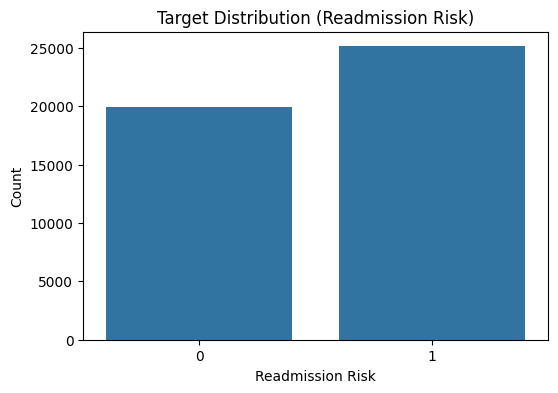

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(x='readmission_risk', data=df)
plt.title("Target Distribution (Readmission Risk)")
plt.xlabel("Readmission Risk")
plt.ylabel("Count")
plt.show()

## Feature Selection

The following variables are selected as predictors:
- age_breakdown
- sex_breakdown
- diagnosis_breakdown
- method
- breakdown
- numerator
- denominator
- expected

In [10]:
X = df[['age_breakdown', 'sex_breakdown', 'diagnosis_breakdown', 'method', 'breakdown',
        'numerator', 'denominator', 'expected']].copy()

y = df['readmission_risk']

print("Features preview:")
print(X.head())

print("\nTarget preview:")
print(y.head())

Features preview:
  age_breakdown sex_breakdown    diagnosis_breakdown method breakdown  \
0           All       Persons  Stroke (I61* to I64*)  Trend   England   
1           All       Persons  Stroke (I61* to I64*)  Trend   England   
2           All       Persons  Stroke (I61* to I64*)  Trend   England   
3           All       Persons  Stroke (I61* to I64*)  Trend   England   
4           All       Persons  Stroke (I61* to I64*)  Trend   England   

  numerator denominator  expected  
0      6630       57268    6630.0  
1      6816       58520    6774.9  
2      6834       58586    6782.6  
3      7049       59663    6907.3  
4      7406       60672    7024.1  

Target preview:
0    0
1    0
2    0
3    0
4    1
Name: readmission_risk, dtype: int64


## Data Preprocessing

This step includes:
- converting numeric columns properly
- handling missing values
- cleaning categorical text
- one-hot encoding categorical features
- scaling numeric variables

In [11]:
# Numeric columns
numeric_cols = ['numerator', 'denominator', 'expected']

for col in numeric_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')
    X[col].fillna(0, inplace=True)



C:\Users\O M E N\AppData\Local\Temp\ipykernel_12108\2161333144.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  X[col].fillna(0, inplace=True)


In [12]:
# Categorical columns
categorical_cols = ['age_breakdown', 'sex_breakdown', 'diagnosis_breakdown', 'method', 'breakdown']

for col in ['diagnosis_breakdown', 'method']:
    X[col] = X[col].astype(str).str.replace("*", "", regex=False)\
                               .str.replace("(", "", regex=False)\
                               .str.replace(")", "", regex=False)

In [13]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_encoded = X_encoded.astype(float)

print("Encoded features preview:")
print(X_encoded.head())

print("Number of features after encoding:", X_encoded.shape[1])

Encoded features preview:
   numerator  denominator  expected  sex_breakdown_Male  \
0     6630.0      57268.0    6630.0                 0.0   
1     6816.0      58520.0    6774.9                 0.0   
2     6834.0      58586.0    6782.6                 0.0   
3     7049.0      59663.0    6907.3                 0.0   
4     7406.0      60672.0    7024.1                 0.0   

   sex_breakdown_Persons  diagnosis_breakdown_Stroke I61 to I64  \
0                    1.0                                    1.0   
1                    1.0                                    1.0   
2                    1.0                                    1.0   
3                    1.0                                    1.0   
4                    1.0                                    1.0   

   breakdown_CCG/sub-ICB  breakdown_Deprivation quintile  breakdown_England  \
0                    0.0                             0.0                1.0   
1                    0.0                             0.0  

In [14]:
# Fill remaining NaN values
X_encoded = X_encoded.fillna(X_encoded.mean())

In [15]:
# Scale numeric features
scaler = StandardScaler()
numeric_features = ['numerator', 'denominator', 'expected']
X_encoded[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])

## Exploratory Data Analysis (EDA)

We now explore the dataset visually to understand the distribution of readmission rates and their relationship with other variables.

### Figure 1: Histogram of Indicator Value

This plot shows the distribution of readmission percentages in the dataset.

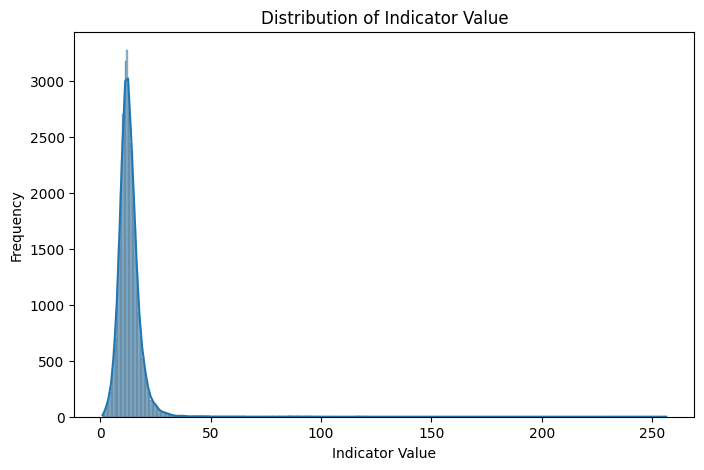

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['indicator_value'], kde=True)
plt.title("Distribution of Indicator Value")
plt.xlabel("Indicator Value")
plt.ylabel("Frequency")
plt.show()

### Figure 2: Boxplot of Readmission Rate by Age Group

This plot compares indicator values across age groups.

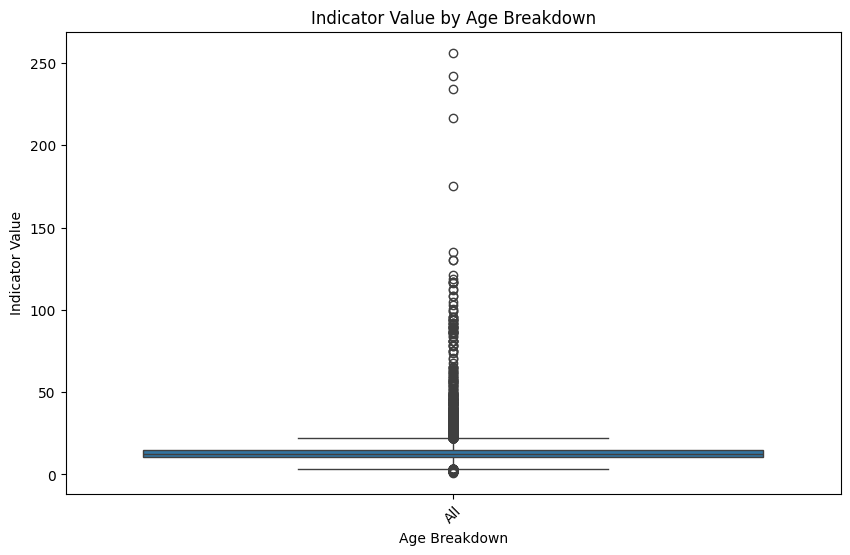

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x='age_breakdown', y='indicator_value', data=df)
plt.title("Indicator Value by Age Breakdown")
plt.xlabel("Age Breakdown")
plt.ylabel("Indicator Value")
plt.xticks(rotation=45)
plt.show()

### Figure 3: Boxplot of Readmission Rate by Diagnosis

This plot compares indicator values across diagnosis categories.

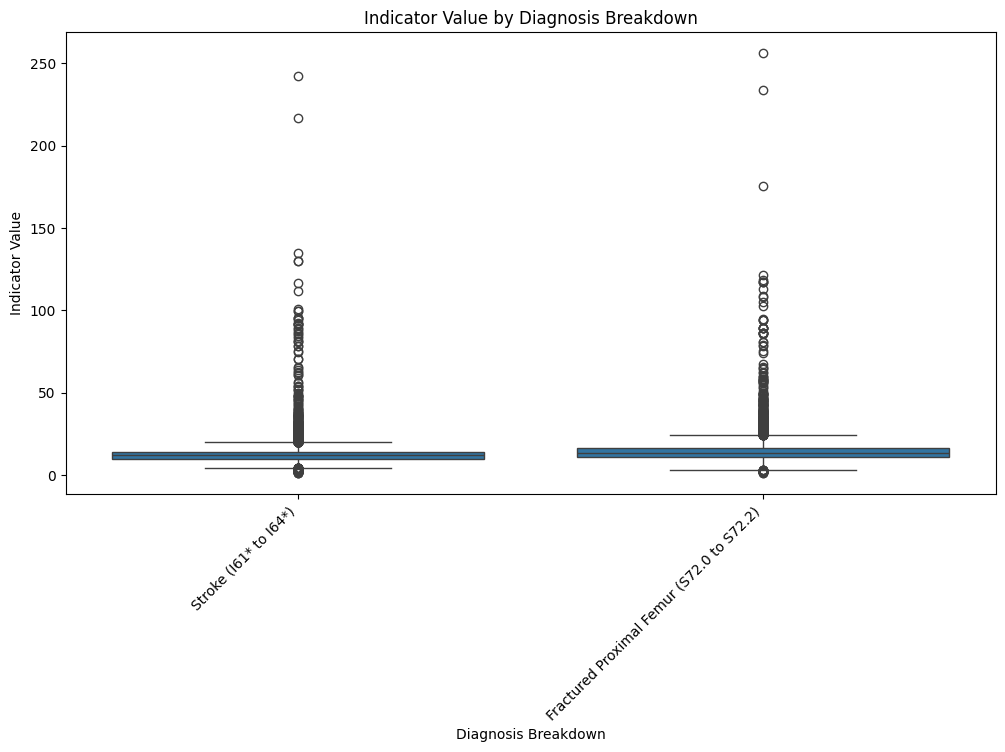

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(x='diagnosis_breakdown', y='indicator_value', data=df)
plt.title("Indicator Value by Diagnosis Breakdown")
plt.xlabel("Diagnosis Breakdown")
plt.ylabel("Indicator Value")
plt.xticks(rotation=45, ha='right')
plt.show()

### Figure 4: Correlation Heatmap

The heatmap shows relationships between numeric variables.

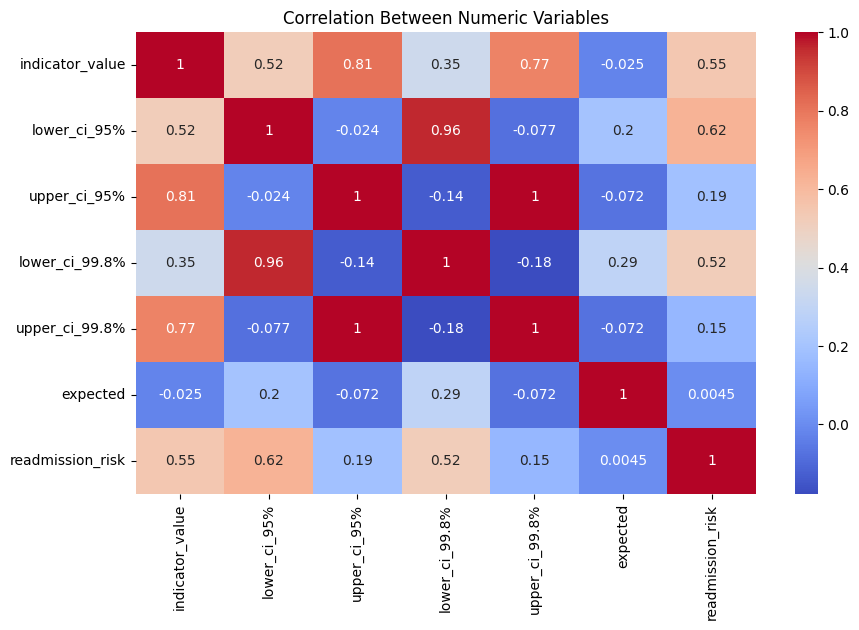

In [19]:
corr = df.select_dtypes(include=['float64', 'int64']).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Variables")
plt.show()

### Pairwise Relationships Between Numeric Variables

This pairplot shows the distributions and pairwise relationships among key numeric variables in the dataset.

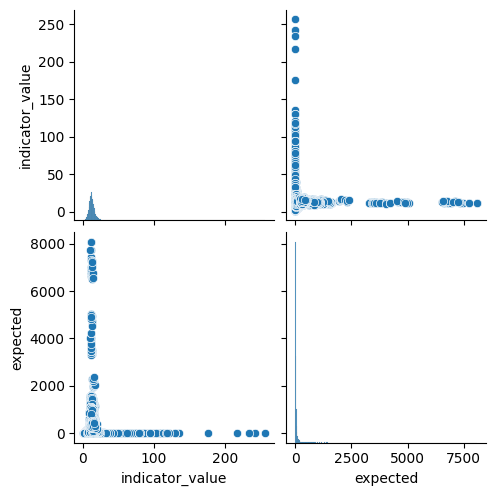

In [64]:
sns.pairplot(df[['indicator_value', 'numerator', 'denominator', 'expected']])
plt.show()

## Train-Test Split

The dataset is split into training and testing sets using an 80/20 ratio. Stratification is applied to preserve the target class distribution.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (36076, 14)
X_test shape: (9019, 14)


## Model 1: Logistic Regression

Logistic Regression is used as a baseline classification model.

In [21]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression Precision:", precision_score(y_test, y_pred))
print("Logistic Regression Recall:", recall_score(y_test, y_pred))
print("Logistic Regression F1 Score:", f1_score(y_test, y_pred))

Logistic Regression Accuracy: 0.6131500166315556
Logistic Regression Precision: 0.6428438834230555
Logistic Regression Recall: 0.6887430389817024
Logistic Regression F1 Score: 0.6650024003840614


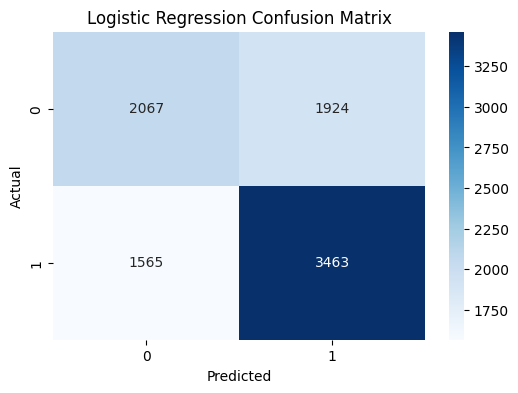

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.52      0.54      3991
           1       0.64      0.69      0.67      5028

    accuracy                           0.61      9019
   macro avg       0.61      0.60      0.60      9019
weighted avg       0.61      0.61      0.61      9019



In [24]:
# Logistic Regression Coefficients
coefficients = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': lr_model.coef_[0]
})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("Top features impacting readmission risk:")
coefficients.head(15)

Top features impacting readmission risk:


,Feature,Coefficient,Abs_Coefficient
0,numerator,0.727804,0.727804
5,diagnosis_breakdown_Stroke I61 to I64,-0.709112,0.709112
9,breakdown_Lower tier local authority,-0.443085,0.443085
1,denominator,-0.391822,0.391822
2,expected,-0.374423,0.374423
7,breakdown_Deprivation quintile,-0.292369,0.292369
6,breakdown_CCG/sub-ICB,-0.247687,0.247687
8,breakdown_England,0.222986,0.222986
11,breakdown_Provider,-0.186988,0.186988
13,breakdown_STP/ICB,-0.164765,0.164765


## Model 2: Decision Tree

Decision Tree is used to capture nonlinear relationships and provide interpretable feature importance.

In [25]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Decision Tree Precision:", precision_score(y_test, dt_pred))
print("Decision Tree Recall:", recall_score(y_test, dt_pred))
print("Decision Tree F1 Score:", f1_score(y_test, dt_pred))

Decision Tree Accuracy: 0.8645082603392837
Decision Tree Precision: 0.8813627254509018
Decision Tree Recall: 0.8747016706443914
Decision Tree F1 Score: 0.8780195647833899


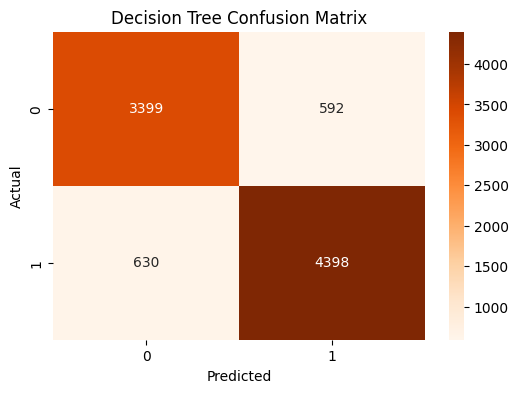

In [26]:
cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top features by importance in Decision Tree:")
feature_importance.head(15)

Top features by importance in Decision Tree:


,Feature,Importance
2,expected,0.358521
0,numerator,0.356221
1,denominator,0.189578
5,diagnosis_breakdown_Stroke I61 to I64,0.036061
3,sex_breakdown_Male,0.018393
4,sex_breakdown_Persons,0.012327
6,breakdown_CCG/sub-ICB,0.009908
11,breakdown_Provider,0.009305
9,breakdown_Lower tier local authority,0.008791
13,breakdown_STP/ICB,0.000513


## Model 3: Random Forest

Random Forest is an ensemble model that improves performance by combining multiple decision trees.

In [28]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest Precision:", precision_score(y_test, rf_pred))
print("Random Forest Recall:", recall_score(y_test, rf_pred))
print("Random Forest F1 Score:", f1_score(y_test, rf_pred))

Random Forest Accuracy: 0.870273866282293
Random Forest Precision: 0.8794256490952006
Random Forest Recall: 0.8892203659506762
Random Forest F1 Score: 0.8842958860759493


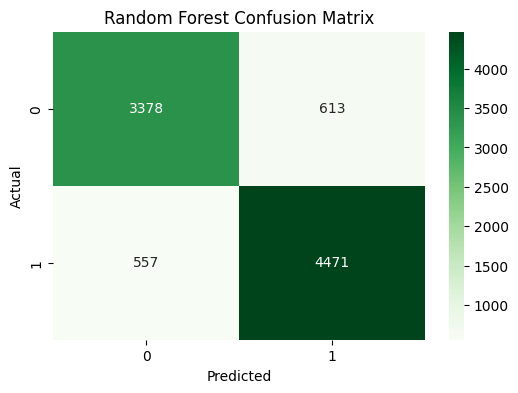

In [29]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
rf_feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top features by importance in Random Forest:")
rf_feature_importance.head(15)

Top features by importance in Random Forest:


,Feature,Importance
0,numerator,0.383986
2,expected,0.321033
1,denominator,0.216359
5,diagnosis_breakdown_Stroke I61 to I64,0.038072
3,sex_breakdown_Male,0.015165
4,sex_breakdown_Persons,0.007920
9,breakdown_Lower tier local authority,0.005608
11,breakdown_Provider,0.004504
6,breakdown_CCG/sub-ICB,0.003022
13,breakdown_STP/ICB,0.002146


## Model 4: XGBoost

XGBoost is a gradient boosting model used to achieve stronger predictive performance on structured data.

In [31]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("XGBoost Precision:", precision_score(y_test, xgb_pred))
print("XGBoost Recall:", recall_score(y_test, xgb_pred))
print("XGBoost F1 Score:", f1_score(y_test, xgb_pred))

c:\Users\O M E N\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:04:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8853531433640093
XGBoost Precision: 0.884334103156274
XGBoost Recall: 0.9138822593476531
XGBoost F1 Score: 0.8988654147104851


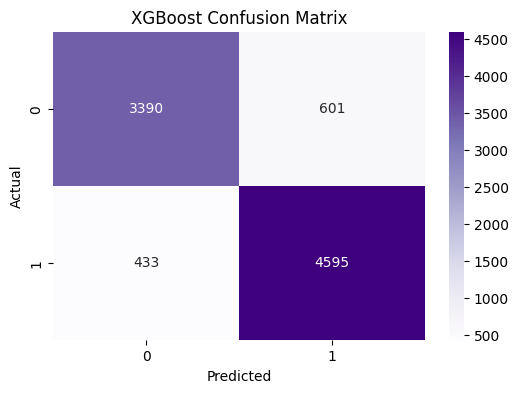

In [32]:
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
xgb_feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top features by importance in XGBoost:")
xgb_feature_importance.head(15)

Top features by importance in XGBoost:


,Feature,Importance
0,numerator,0.276963
1,denominator,0.220708
5,diagnosis_breakdown_Stroke I61 to I64,0.173098
2,expected,0.142361
3,sex_breakdown_Male,0.067715
11,breakdown_Provider,0.037951
4,sex_breakdown_Persons,0.017251
8,breakdown_England,0.016040
9,breakdown_Lower tier local authority,0.013343
6,breakdown_CCG/sub-ICB,0.012366


## Hyperparameter Tuning

Hyperparameter tuning was performed to optimize selected tree-based models and improve predictive performance.

### XGBoost Hyperparameter Tuning

In [ ]:

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

best_xgb = grid_search.best_estimator_
best_xgb_pred = best_xgb.predict(X_test)

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, best_xgb_pred))
print("Tuned XGBoost Precision:", precision_score(y_test, best_xgb_pred))
print("Tuned XGBoost Recall:", recall_score(y_test, best_xgb_pred))
print("Tuned XGBoost F1 Score:", f1_score(y_test, best_xgb_pred))

c:\Users\O M E N\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:17:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 150}
Best Cross-Validation F1 Score: 0.8946535844957447
Tuned XGBoost Accuracy: 0.8862401596629338
Tuned XGBoost Precision: 0.8805629516926589
Tuned XGBoost Recall: 0.9208432776451869
Tuned XGBoost F1 Score: 0.9002527707563679


In [59]:
tuning_comparison = pd.DataFrame({
    "Model": ["Original XGBoost", "Tuned XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, best_xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, xgb_pred),
        precision_score(y_test, best_xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, xgb_pred),
        recall_score(y_test, best_xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, xgb_pred),
        f1_score(y_test, best_xgb_pred)
    ]
})

tuning_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Original XGBoost,0.885353,0.884334,0.913882,0.898865
1,Tuned XGBoost,0.886240,0.880563,0.920843,0.900253


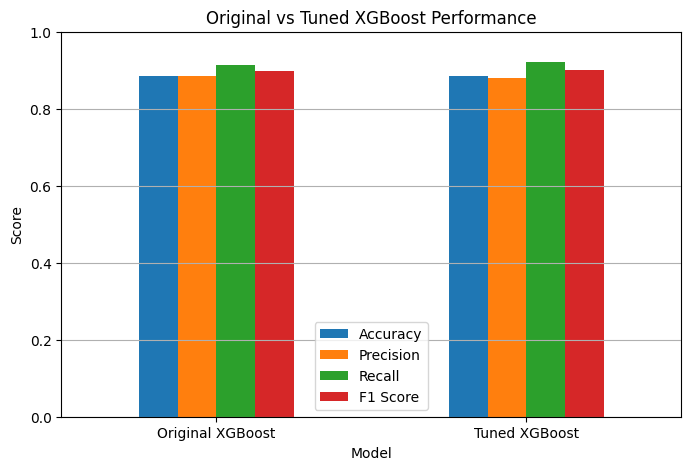

In [60]:
tuning_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]]\
    .plot(kind="bar", figsize=(8,5))

plt.title("Original vs Tuned XGBoost Performance")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### Hyperparameter Tuning Results

Hyperparameter tuning was performed on the XGBoost model using GridSearchCV. The tuned model showed a slight improvement in overall performance.

The F1 Score increased from 0.8989 to 0.9003, indicating a better balance between precision and recall. Additionally, recall improved from 0.9139 to 0.9208, meaning the tuned model is more effective at identifying high-risk readmission cases.

Although precision decreased slightly, this trade-off is acceptable in a healthcare context where correctly identifying high-risk patients is more critical than avoiding false positives.

Overall, the tuned XGBoost model is selected as the final model due to its improved performance.

## Model Comparison

The performance of all four classification models is compared using Accuracy, Precision, Recall, and F1 Score.

In [34]:
lr_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred)
}

dt_metrics = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, dt_pred),
    "Precision": precision_score(y_test, dt_pred),
    "Recall": recall_score(y_test, dt_pred),
    "F1 Score": f1_score(y_test, dt_pred)
}

rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1 Score": f1_score(y_test, rf_pred)
}

xgb_metrics = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1 Score": f1_score(y_test, xgb_pred)
}

comparison_df = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics, xgb_metrics])
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.885353,0.884334,0.913882,0.898865
2,Random Forest,0.870274,0.879426,0.889220,0.884296
1,Decision Tree,0.864508,0.881363,0.874702,0.878020
0,Logistic Regression,0.613150,0.642844,0.688743,0.665002


### Multi-Metric Model Comparison

This chart compares Accuracy, Precision, Recall, and F1 Score across all classification models.

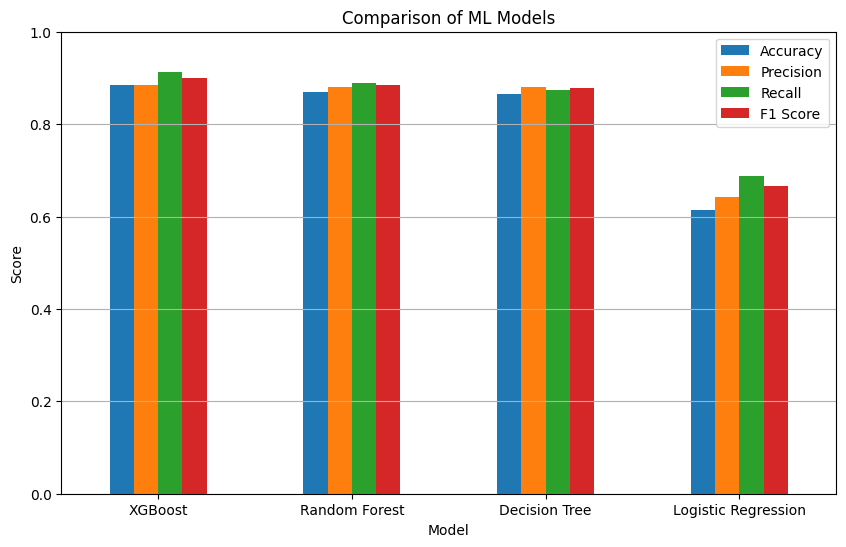

In [47]:
metrics_df = comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']]

metrics_df.plot(kind='bar', figsize=(10,6))
plt.title("Comparison of ML Models")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### Figure 6: F1 Score Comparison

This bar chart compares F1 Scores across all models.

C:\Users\O M E N\AppData\Local\Temp\ipykernel_12108\2918591195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="F1 Score", y="Model", data=comparison_df, palette="coolwarm")


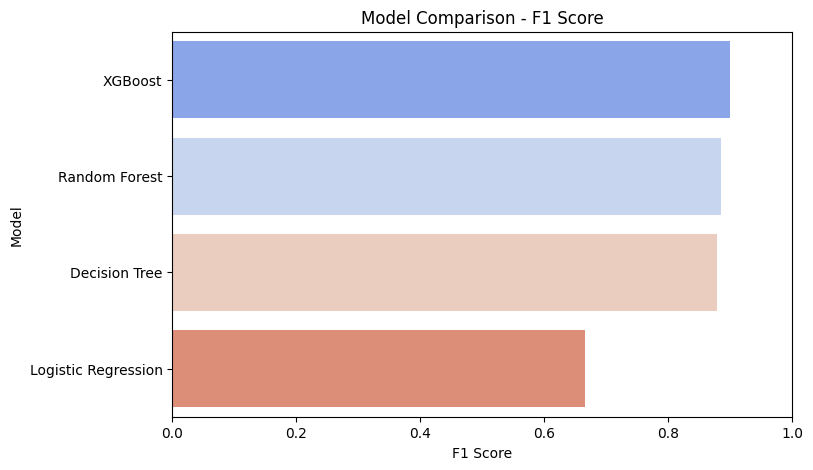

In [35]:
plt.figure(figsize=(8,5))
sns.barplot(x="F1 Score", y="Model", data=comparison_df, palette="coolwarm")
plt.title("Model Comparison - F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

C:\Users\O M E N\AppData\Local\Temp\ipykernel_12108\1154196285.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=comparison_df, palette="viridis")


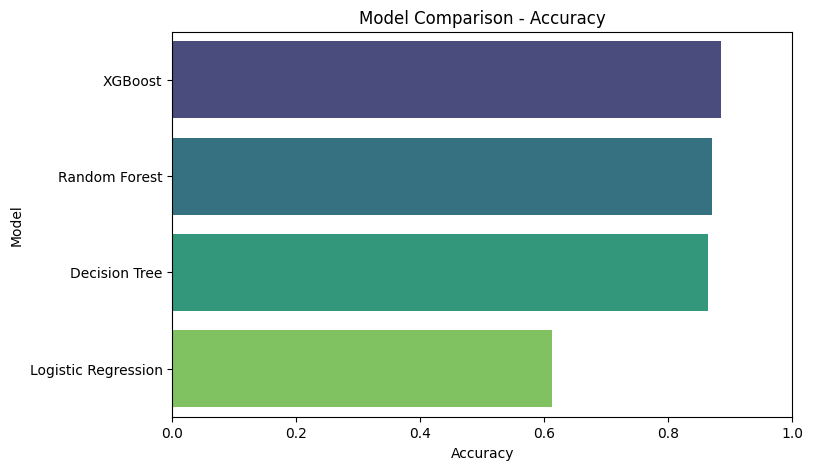

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(x="Accuracy", y="Model", data=comparison_df, palette="viridis")
plt.title("Model Comparison - Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

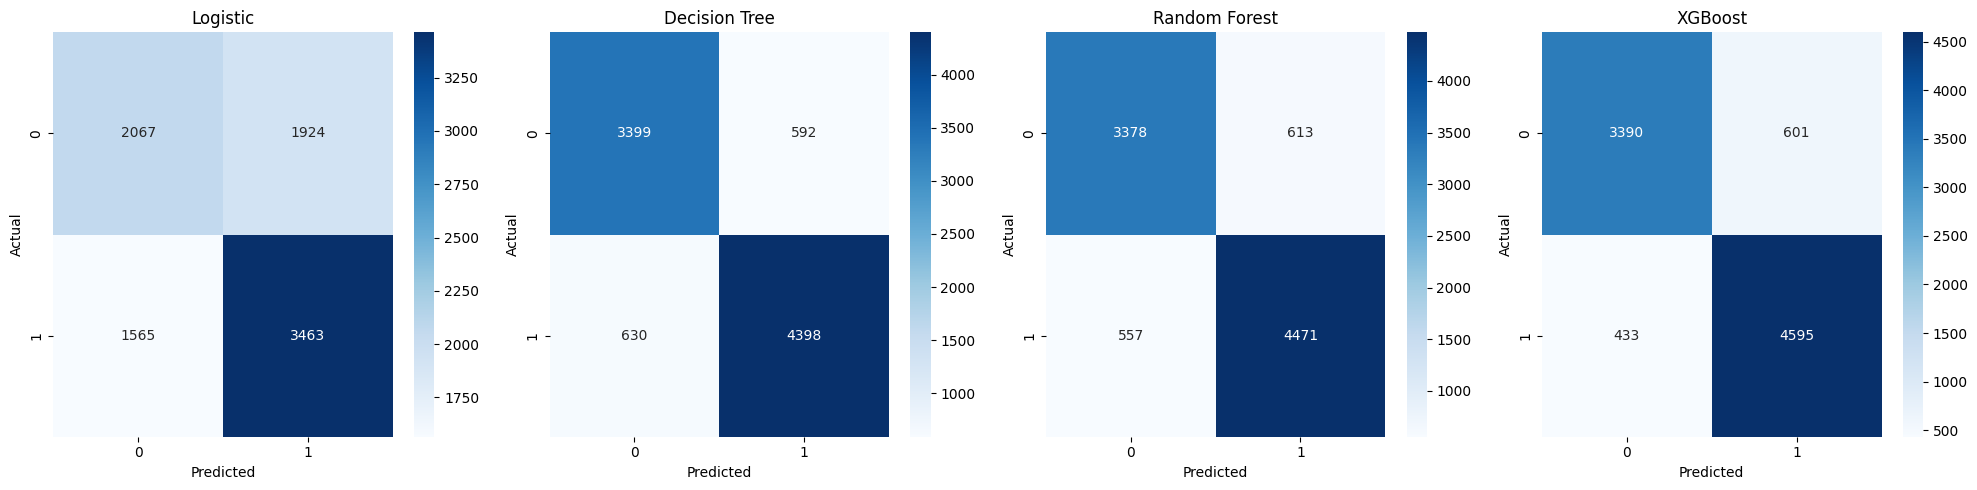

In [57]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))

models_preds = [
    ("Logistic", y_pred),
    ("Decision Tree", dt_pred),
    ("Random Forest", rf_pred),
    ("XGBoost", xgb_pred)
]

for ax, (name, pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### Predicted Probability Comparison
This table shows the predicted probability of high readmission risk for each model.

In [56]:
probability_comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Logistic_Prob": lr_model.predict_proba(X_test)[:, 1],
    "DecisionTree_Prob": dt_model.predict_proba(X_test)[:, 1],
    "RandomForest_Prob": rf_model.predict_proba(X_test)[:, 1],
    "XGBoost_Prob": xgb_model.predict_proba(X_test)[:, 1]
})

probability_comparison.head(20)

,Actual,Logistic_Prob,DecisionTree_Prob,RandomForest_Prob,XGBoost_Prob
0,0,0.495251,0.000000,0.130000,0.019462
1,0,0.659348,0.000000,0.050000,0.325482
2,1,0.490006,1.000000,0.970000,0.990961
3,1,0.465433,1.000000,0.990000,0.834119
4,1,0.440989,1.000000,0.990000,0.998958
5,0,0.488038,0.000000,0.040000,0.002796
6,1,0.461604,0.000000,0.440000,0.693171
7,1,0.435836,1.000000,0.990000,0.986461
8,1,0.487614,1.000000,0.830000,0.628064
9,0,0.633412,0.000000,0.110000,0.010220


### ROC Curve Comparison

This plot compares the classification performance of all models across different probability thresholds.

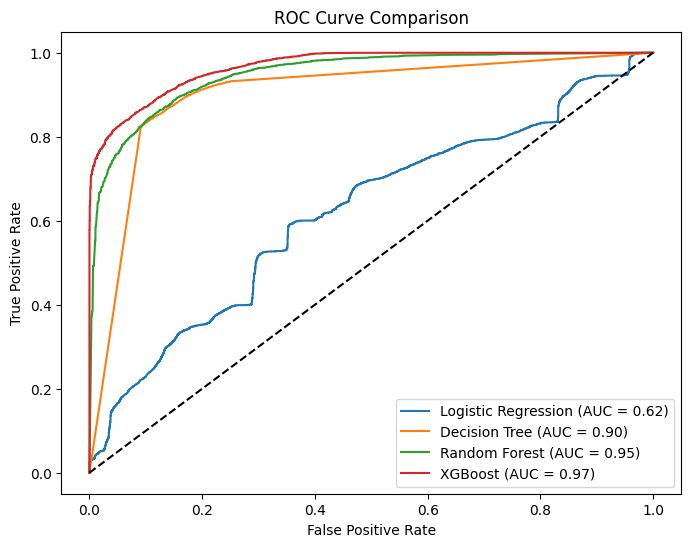

In [ ]:


lr_probs = lr_model.predict_proba(X_test)[:, 1]
dt_probs = dt_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.2f})")
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### ROC Insight

The ROC curve shows how well each model separates high-risk and low-risk readmission cases across different thresholds. A curve closer to the top-left corner indicates better classification performance.

## Best Model Selection

The best-performing model is selected based on the evaluation metrics, especially the F1 Score.

In [37]:
best_model_name = comparison_df.iloc[0]["Model"]
print(f"Based on the evaluation metrics, the best-performing model is {best_model_name}.")

Based on the evaluation metrics, the best-performing model is XGBoost.


## Feature Importance Visualization

Tree-based models provide feature importance scores, helping identify which variables contribute most to predictions.

In [38]:
def plot_feature_importance(feature_df, model_name, top_n=10):
    top_features = feature_df.head(top_n)
    plt.figure(figsize=(10,6))
    sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
    plt.title(f"Top {top_n} Features Impacting Readmission Risk - {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

C:\Users\O M E N\AppData\Local\Temp\ipykernel_12108\3958029411.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


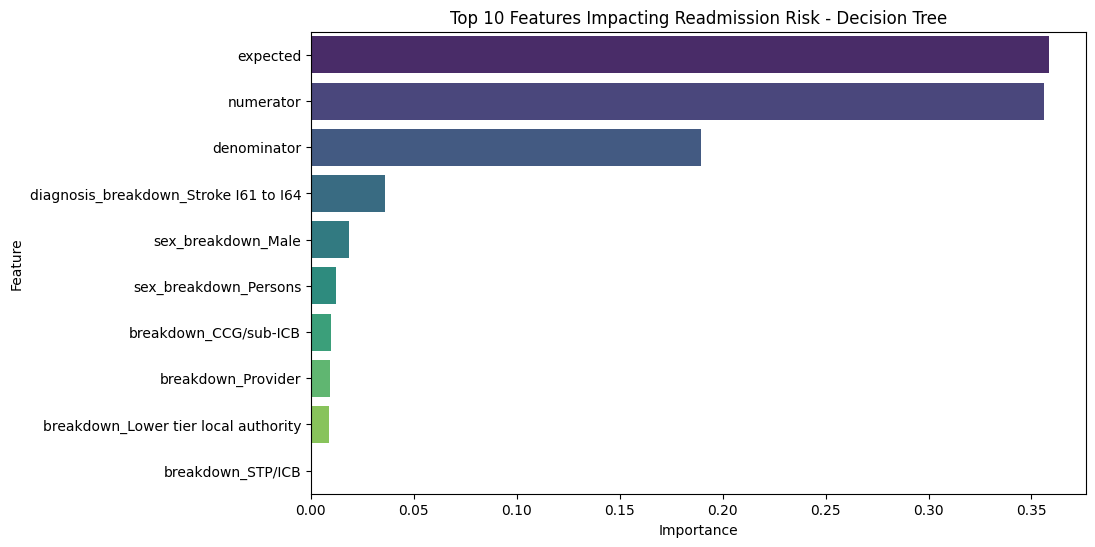

In [39]:
# Decision Tree
plot_feature_importance(feature_importance, "Decision Tree")

C:\Users\O M E N\AppData\Local\Temp\ipykernel_12108\3958029411.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


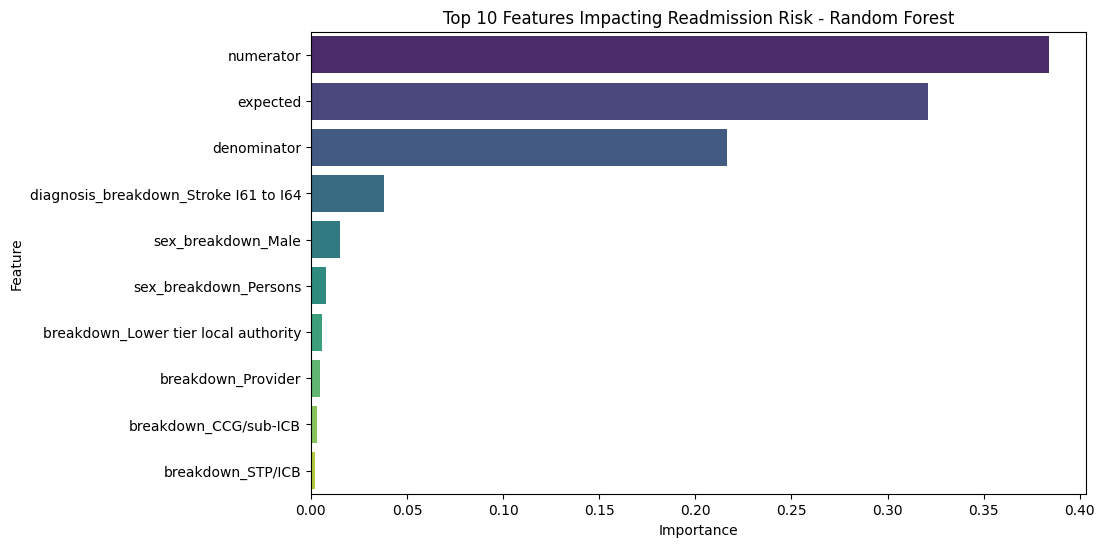

In [40]:
# Random Forest
plot_feature_importance(rf_feature_importance, "Random Forest")

### Figure 7: XGBoost Feature Importance

This chart shows the top predictors in the XGBoost model.

C:\Users\O M E N\AppData\Local\Temp\ipykernel_12108\3958029411.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


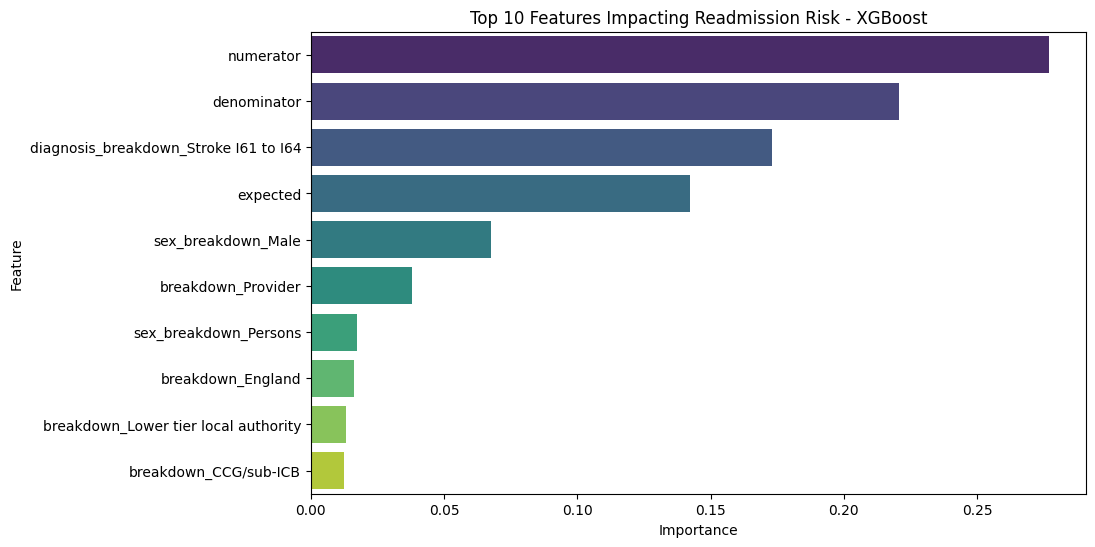

In [41]:
# XGBoost
plot_feature_importance(xgb_feature_importance, "XGBoost")

### Feature Importance Insight

The variables "denominator", "expected", and "numerator" appear as the most influential predictors, indicating their strong relationship with readmission risk.

## Results & Interpretation

Among all evaluated models, XGBoost achieved the best performance due to its ability to capture complex nonlinear patterns in structured healthcare data. Logistic Regression provides a useful baseline, while Decision Tree and Random Forest offer interpretable tree-based alternatives.

## Limitations

This study has a few limitations:

1. The target variable is created using a threshold on `indicator_value`, which may simplify the true readmission risk pattern.
2. Some predictor variables may be strongly related to the target, which can increase the risk of leakage.
3. A random train-test split was used instead of time-based validation.
4. The dataset contains limited clinical and patient-level information.

## Conclusion

This notebook demonstrated the use of machine learning models for predicting hospital readmission risk. Four classification models were trained and evaluated: Logistic Regression, Decision Tree, Random Forest, and XGBoost. Based on the evaluation metrics, XGBoost achieved the strongest overall performance, making it the most suitable model in this study for identifying high-risk readmission cases.

## Future Work

Possible future improvements include:

- adding a Neural Network model for comparison
- extending hyperparameter tuning to other models
- using cross-validation
- further analysis of model performance using additional evaluation techniques
- using SHAP for interpretability
- implementing time-based validation